# **X-Ray Lung Diseases Images**


---



###**1. Sobre o Dataset**

O dataset intitulado 'X-Ray Lung Diseases Images', disponivel no kaggle pelo link: https://www.kaggle.com/datasets/fernando2rad/x-ray-lung-diseases-images-9-classes, é um conjunto de dados de imagens de raio-x da área superior do tórax, deabrangendo desde condições normais até patologias complexas, como alterações de mediastino (incluindo pericardite, malformações arteriovenosas e linfonodomegalias), além de outras afecções pulmonares. Composto com 6743 imagens, é dividido em imagens de abragências médicas diferente, sendo 9 ao todo:

1. Normal - Exames sem anormalidades detectáveis
2. Inflammatory processes - Pneumonia e condições inflamatórias
3. Higher density - Inclui: Derrame pleural, Consolidação, atelectática, Hidrotórax, Empiema;
4. Lower density - Inclui: Pneumotórax, Pneumomediastino, Pneumoperitônio;
5. Obstructive pulmonary diseases - Inclui: Enfisema, Broncopneumonia, Bronquiectasias, Embolismo
6. Degenerative infectious diseases - Inclui: Tuberculose, Sarcoidose, Proteinose, Fibrose;
7. Encapsulated lesions - Inclui: Abscessos, Nódulos, Cistos, Massas tumorais, Metástases;
8. Mediastinal changes - Inclui: Pericardite, Malformações, arteriovenosas, Aumento de linfonodos;
9. Chest changes - Inclui: Atelectasia, Malformações, Agenesia, Hipoplasia.




---




###**2. Visualização dos dados e Pré-Processamento**

Para compreender melhor o conjunto de dados e avaliar a qualidade das imagens antes do tratamento, foram realizadas algumas visualizações exploratórias. Essas visualizações permitiram verificar a estrutura das imagens, a distribuição das classes e identificar eventuais variações de contraste ou tamanho.

Após esta etapa inicial, foi aplicado um pré-processamento adequado para imagens de raio-X, consistindo em:

* Padronização do **tamanho das imagens**;
* **Normalização dos valores de pixel** para o intervalo entre 0 e 1
(não foi aplicada equalização global do histograma, uma vez que essa técnica pode alterar padrões clínicos relevantes em radiografias).

Ao final do pré-processamento, passamos a trabalhar com dois dataframes distintos no código:

**df_preprocessed**: contendo as imagens padronizadas e normalizadas

**df_original:**  contendo informações e caminhos das imagens originais, sem modificações

---



#### **2.1 Bibliotecas e importação do dataset**

Inicialmente, importamos as bibliotecas essenciais para o projeto. Em seguida, baixamos o dataset de imagens usando kagglehub e mapeamos os caminhos para a pasta principal e suas subpastas, que representam as classes (labels) a serem processadas.

In [ ]:
import kagglehub
import os
import pandas as pd
import numpy as np
import random
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model
from torch.optim.lr_scheduler import ReduceLROnPlateau
from skimage import io, color
from skimage.feature import graycomatrix, graycoprops, canny, local_binary_pattern
from scipy.stats import skew, kurtosis
from PIL import Image
from PIL import ImageOps
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

from tqdm import tqdm

import torch
import torch.nn
from torch import flatten
from torch.autograd import Variable
from torch.nn import LazyLinear, Linear, ReLU,MSELoss, CrossEntropyLoss, Sequential, Conv2d, MaxPool2d, Module, Softmax, BatchNorm2d, Dropout, ConvTranspose2d, Sigmoid, functional, AdaptiveAvgPool2d
from torch.optim import Adam, SGD

In [ ]:
from google.colab import drive
drive.mount('/content/drive')#Para salvar dados pre-processados

Mounted at /content/drive


In [ ]:
path = kagglehub.dataset_download("fernando2rad/x-ray-lung-diseases-images-9-classes")
files_in_directory = os.listdir(path)
print(files_in_directory)
# folder_path = os.path.join(path, 'chest_xray')
# subdirectories = os.listdir(folder_path)

100%|██████████| 182M/182M [00:01<00:00, 114MB/s] 

Extracting files...


['00 Anatomia Normal', '06 Lesões Encapsuladas (Abscessos, Nódulos, Cistos, Massas Tumorais, Metastases)', '02 Maior Densidade (Derrame Pleural, Consolidação Atelectasica, Hidrotorax, Empiema)', '01 Processos Inflamatórios Pulmonares (Pneumonia)', '07 Alterações de Mediastino (Pericardite, Malformações Arteriovenosas, Linfonodomegalias)', '05 Doenças Infecciosas Degenerativas (Tuberculose, Sarcoidose, Proteinose, Fibrose)', '08 Alterações do Tórax (Atelectasias, Malformações, Agenesia, Hipoplasias)', '03 Menor Densidade (Pneumotorax, Pneumomediastino, Pneumoperitonio)', '04 Doenças Pulmonares Obstrutivas (Enfisema, Broncopneumonia, Bronquiectasia, Embolia)']


In [ ]:
FULL_LABEL_TO_LABEL =  {
    "04 Doenças Pulmonares Obstrutivas (Enfisema, Broncopneumonia, Bronquiectasia, Embolia)" : "Obstrutivas",
    "02 Maior Densidade (Derrame Pleural, Consolidação Atelectasica, Hidrotorax, Empiema)" : "Maior-Densidade",
    "03 Menor Densidade (Pneumotorax, Pneumomediastino, Pneumoperitonio)" : "Menor-Densidade",
    "08 Alterações do Tórax (Atelectasias, Malformações, Agenesia, Hipoplasias)" : "Alteracoes-Torax",
    "06 Lesões Encapsuladas (Abscessos, Nódulos, Cistos, Massas Tumorais, Metastases)": "Lesoes",
    "05 Doenças Infecciosas Degenerativas (Tuberculose, Sarcoidose, Proteinose, Fibrose)": "Degenerativo",
    "00 Anatomia Normal": "Normal",
    "07 Alterações de Mediastino (Pericardite, Malformações Arteriovenosas, Linfonodomegalias)":"Alteracoes-Midastino",
    "01 Processos Inflamatórios Pulmonares (Pneumonia)":"Inflamatorio"
}
MIN_LABEL_TO_INTEGER = {
    "Normal": 0,
    "Inflamatorio": 1,
    "Menor-Densidade": 3,
    "Maior-Densidade": 2,
    "Obstrutivas": 4,
    "Degenerativo": 5,
    "Lesoes": 6,
    "Alteracoes-Midastino": 7,
    "Alteracoes-Torax":8
}


####**2.2 Visualização geral das imagens**

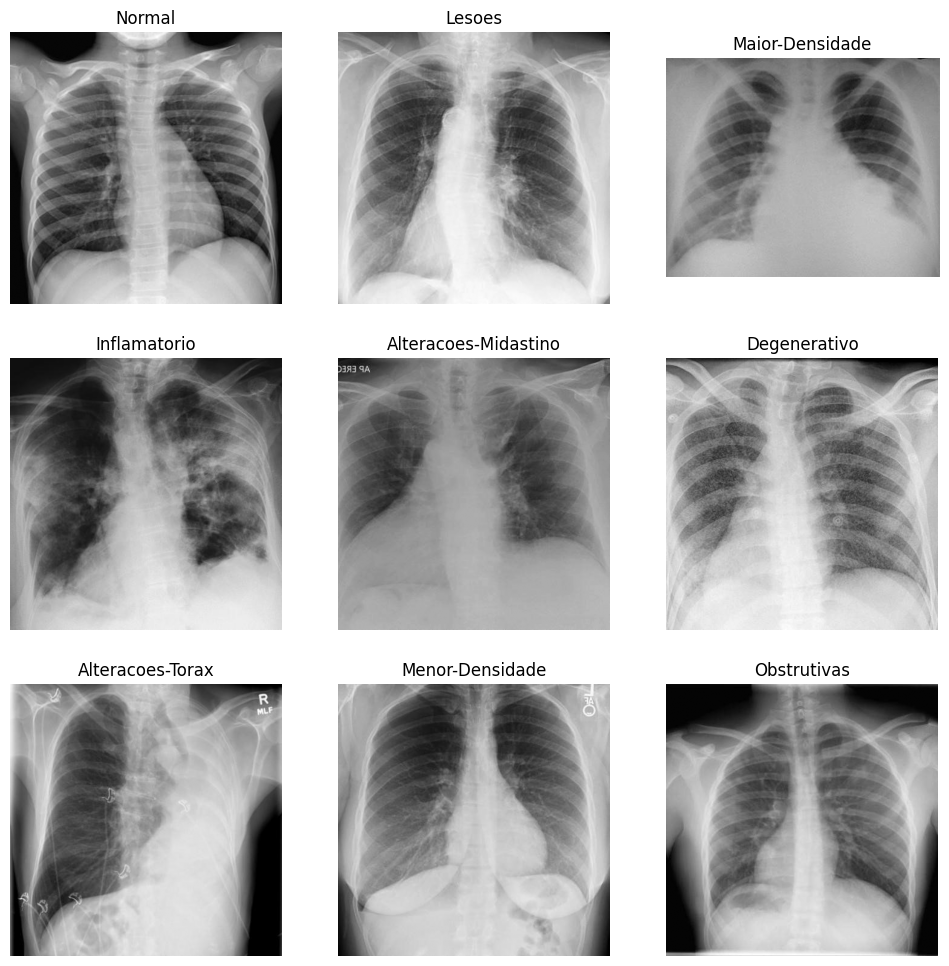

In [ ]:
classes = files_in_directory
plt.figure(figsize=(12,12)) # Adjusted figure size for a 3x3 grid

for i, label in enumerate(classes):
    img_folder = os.path.join(path, label)
    img_name = random.choice(os.listdir(img_folder))
    img_path = os.path.join(img_folder, img_name)
    min_label = FULL_LABEL_TO_LABEL.get(label)
    img = Image.open(img_path)
    plt.subplot(3, 3, i+1)
    plt.imshow(img, cmap="gray")
    plt.title(min_label)
    plt.axis("off")

plt.show()

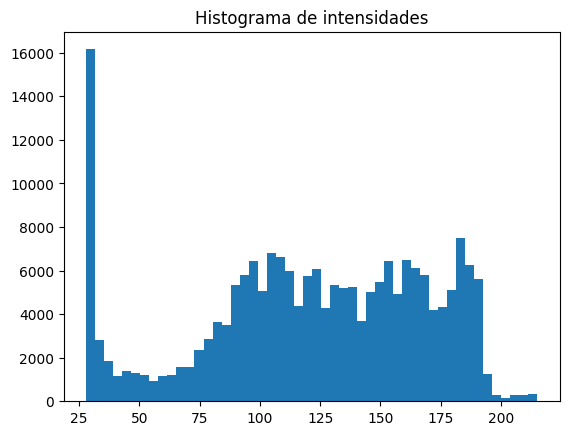

In [ ]:
img_gray = img.convert("L")
plt.hist(img_gray.getdata(), bins=50)
plt.title("Histograma de intensidades")
plt.show()

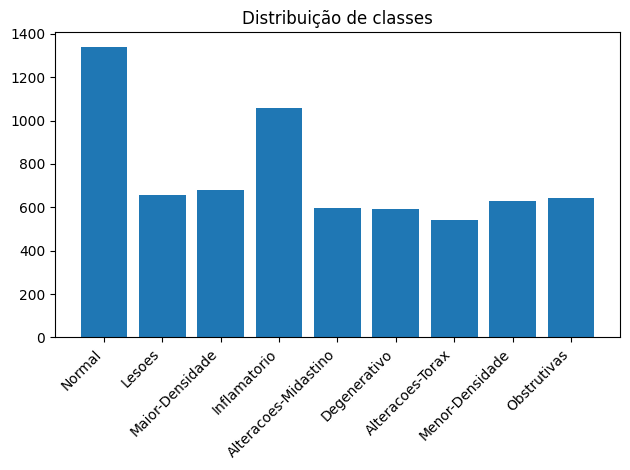

In [ ]:
from collections import Counter

class_count = {}
total_images = 0
for c in classes:
    folder = os.path.join(path, c)
    qtd =  len(os.listdir(folder))
    class_count[FULL_LABEL_TO_LABEL.get(c)] = qtd
    total_images = total_images + qtd

plt.bar(class_count.keys(), class_count.values())
plt.title("Distribuição de classes")
plt.xticks(rotation=45, ha='right')  # rotate labels
plt.tight_layout()                   # adjust layout
plt.show()


In [ ]:
#Class proportion
class_proportion = {}
weights_list = [0] * 9

for c in classes:
    class_id = MIN_LABEL_TO_INTEGER.get(FULL_LABEL_TO_LABEL.get(c))
    qtd = len(os.listdir(os.path.join(path, c)))
    weights_list[class_id] = total_images / qtd
    print(f"{FULL_LABEL_TO_LABEL.get(c)}: {total_images/qtd}")
print(weights_list)

Normal: 5.032089552238806
Lesoes: 10.24772036474164
Maior-Densidade: 9.94542772861357
Inflamatorio: 6.361320754716981
Alteracoes-Midastino: 11.313758389261745
Degenerativo: 11.351851851851851
Alteracoes-Torax: 12.395220588235293
Menor-Densidade: 10.720190779014308
Obstrutivas: 10.470496894409937
[5.032089552238806, 6.361320754716981, 9.94542772861357, 10.720190779014308, 10.470496894409937, 11.351851851851851, 10.24772036474164, 11.313758389261745, 12.395220588235293]




---


####**2.3 Pré-Processamento + Tratamento das imagens**

Considerado a análise feita, precisamos aplicar um pré-processamnto que faça:

*    A padronização do tamanho das imagens, ou seja, mantenha um tamanho fixo para todas;
*   Normalização das imagens (entre 0 e 1).

In [ ]:
def preprocess_image(image_path, size=(112, 112)):

    img = Image.open(image_path).convert("RGB")

    # padronizar tamanho
    img = img.resize(size)

    # converter para array normalizado
    img_arr = np.array(img, dtype="float32") / 255.0

    return img_arr

def build_preprocessed_df(base_path):
    data = {
        "path": [],
        "class": [],
        "image_array": [],
    }

    for cls in files_in_directory:
        class_path = os.path.join(base_path, cls)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            processed = preprocess_image(img_path)

            data["path"].append(img_path)
            data["class"].append(FULL_LABEL_TO_LABEL.get(cls))
            data["image_array"].append(processed)

    df_new = pd.DataFrame(data)
    return df_new

df_preprocessed = None
#Verificar se no drive ja existe arquivo com dados pre-processados. Se atualizar o pre processamento, lembrar de atualizar esse ponto.
if os.path.exists('/content/drive/MyDrive/Trabalho_Machine_Learning/data.pkl'):
    print("Usando cache...")
    df_preprocessed = pd.read_pickle('/content/drive/MyDrive/Trabalho_Machine_Learning/data.pkl')
else:
  print("Processando dados...")
  df_preprocessed = build_preprocessed_df(path)
  print("Salvando dados para uso futuro...")
  df_preprocessed.to_pickle('/content/drive/MyDrive/Trabalho_Machine_Learning/data.pkl')
df_preprocessed.head()

Usando cache...


,path,class,image_array
0,/root/.cache/kagglehub/datasets/fernando2rad/x...,Degenerativo,"[[[0.2784314, 0.34509805, 0.40784314], [0.2705..."
1,/root/.cache/kagglehub/datasets/fernando2rad/x...,Degenerativo,"[[[0.74509805, 0.74509805, 0.74509805], [0.662..."
2,/root/.cache/kagglehub/datasets/fernando2rad/x...,Degenerativo,"[[[0.047058824, 0.047058824, 0.047058824], [0...."
3,/root/.cache/kagglehub/datasets/fernando2rad/x...,Degenerativo,"[[[0.2, 0.2, 0.2], [0.2, 0.2, 0.2], [0.2, 0.2,..."
4,/root/.cache/kagglehub/datasets/fernando2rad/x...,Degenerativo,"[[[0.38039216, 0.38039216, 0.38039216], [0.396..."


In [ ]:
df_preprocessed["image_array"].apply(lambda x: x.shape).unique()

array([(112, 112, 3)], dtype=object)

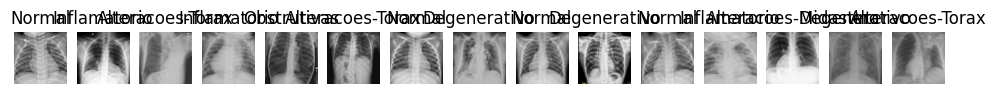

In [ ]:
def visualizar_aleatorio(df, n=5):
    amostras = df.sample(n)

    plt.figure(figsize=(12, 12))

    for i, (_, row) in enumerate(amostras.iterrows()):
        img = row["image_array"]
        label = row["class"]

        plt.subplot(1, n, i+1)
        plt.imshow(img, cmap="gray")
        plt.title(label)
        plt.axis("off")

    plt.show()

# exemplo de uso:
visualizar_aleatorio(df_preprocessed, n=15)


##**3. Aplicação dos algoritmos**

####**3.1 Transformando estrutura dos dados**

In [ ]:
label_to_int = MIN_LABEL_TO_INTEGER
int_to_label = {v: k for k, v in label_to_int.items()}

In [ ]:
df = np.stack(df_preprocessed["image_array"].values)
df.shape

(6743, 112, 112, 3)

In [ ]:
df_labels = np.array([label_to_int[x] for x in df_preprocessed["class"]])
df_labels.shape

(6743,)

In [ ]:

def show_stacked_image(images, idx=0):
    """
    Display one image from a stacked dataset (NumPy array).

    images: np.ndarray of shape (N, H, W, C) or (N, C, H, W)
    idx: index of the image to display
    """
    img = images[idx]

    # If images are in CHW format -> convert to HWC
    if img.ndim == 3 and img.shape[0] in (1, 3):
        img = np.transpose(img, (1, 2, 0))  # CHW -> HWC

    # Clip values if normalized
    if img.dtype != np.uint8:
        img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.title(f"Image {idx}")
    plt.axis("off")
    plt.show()

### 3.2 Dividindo conjunto de dados

In [ ]:
# Criando conjunto de validação
data_x, val_x, data_y, val_y = train_test_split(df, df_labels, test_size = 0.1)
(data_x.shape, data_y.shape), (val_x.shape, val_y.shape)

(((6068, 112, 112, 3), (6068,)), ((675, 112, 112, 3), (675,)))

In [ ]:
#Criando conjunto de teste

train_x, test_x, train_y, test_y = train_test_split(data_x, data_y, test_size = 0.2)
(train_x.shape, train_y.shape), (test_x.shape, test_y.shape)

(((4854, 112, 112, 3), (4854,)), ((1214, 112, 112, 3), (1214,)))

In [ ]:
# Conversão do tipo das imagens para Tensor
# Verificar estrutura dos dados, em tese era pra ser parecido com o notebook
# https://colab.research.google.com/drive/1mV1I9Q4rU0h6FfsP4RMm0Befd4ABXiI-?usp=sharing#scrollTo=MVciYr4r6CRi

train_x = train_x.transpose(0, 3, 1, 2)  # (N, H, W, C) → (N, C, H, W)

#train_x = train_x.reshape(4216, 3, 112, 112)
train_x  = torch.from_numpy(train_x)

# COnversão do tipo dos rótulos para Tensor
train_y = train_y.astype(int);
train_y = torch.from_numpy(train_y)

# Dimensões do conjunto de treinamento
train_x.shape, train_y.shape

(torch.Size([4854, 3, 112, 112]), torch.Size([4854]))

In [ ]:
# Conversão do conjunto de validação para Tensor
#val_x = val_x.reshape(586, 3, 112, 112)
val_x = val_x.transpose(0, 3, 1, 2)
val_x  = torch.from_numpy(val_x)

# Conversão dos rótulos de validação
val_y = val_y.astype(int);
val_y = torch.from_numpy(val_y)

# Dimensão do conjunto de validação
val_x.shape, val_y.shape

(torch.Size([675, 3, 112, 112]), torch.Size([675]))

In [ ]:
# Conversão do conjunto de validação para Tensor
#test_x = test_x.reshape(1054, 3, 112, 112)
test_x = test_x.transpose(0, 3, 1, 2)
test_x  = torch.from_numpy(test_x)

# Conversão dos rótulos de validação
test_y = test_y.astype(int);
test_y = torch.from_numpy(test_y)

# Dimensão do conjunto de validação
test_x.shape, test_y.shape

(torch.Size([1214, 3, 112, 112]), torch.Size([1214]))

In [ ]:
MIN_LABEL_TO_INTEGER.keys()
label_names = list(MIN_LABEL_TO_INTEGER.keys())
print(label_names)

['Normal', 'Inflamatorio', 'Menor-Densidade', 'Maior-Densidade', 'Obstrutivas', 'Degenerativo', 'Lesoes', 'Alteracoes-Midastino', 'Alteracoes-Torax']


#### NORMALIZANDO TENSORES



In [ ]:
mean = train_x.mean(dim=(0, 2, 3))
# Calculate standard deviation across N, H, and W dimensions
std = train_x.std(dim=(0, 2, 3))

print(f"Calculated Mean (per channel): {mean}")
print(f"Calculated Std (per channel): {std}")

Calculated Mean (per channel): tensor([0.5445, 0.5451, 0.5453])
Calculated Std (per channel): tensor([0.2078, 0.2078, 0.2078])


In [ ]:
normalize = transforms.Normalize(mean=mean.tolist(), std=std.tolist())
train_x = normalize(train_x)
val_x = normalize(val_x)
test_x = normalize(test_x)

In [ ]:
print(f"Calculated Mean (per channel): {train_x.mean(dim=(0, 2, 3))}")
print(f"Calculated Std (per channel): {train_x.std(dim=(0, 2, 3))}")

Calculated Mean (per channel): tensor([ 1.8023e-07, -2.4310e-07, -2.0974e-07])
Calculated Std (per channel): tensor([1., 1., 1.])


### 3.3 CNN Simples

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
from torch import flatten

class CNN(Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.softmax = Softmax()

        self.cnn_layers = Sequential(
            # Definindo camada de convolução 2D
            Conv2d(3, 4, kernel_size=3, stride=1, padding=1), # De 3 canais(1° arg) vai para 4 (2° arg). Mantem tamanho pelo padding 1.
            ##Normalização
            BatchNorm2d(4), #Normalizacao em 4 canais
            ReLU(inplace=True),
            ###Subamostragem
            MaxPool2d(kernel_size=2, stride=2), #Resulta em 4x56x56 (por conta do stride=2)
            # Definindo camada de convolução 2D
            Conv2d(4, 4, kernel_size=3, stride=1, padding=1),
            BatchNorm2d(4),
            ReLU(inplace=True),
            MaxPool2d(kernel_size=2, stride=2),# 4x28x28
        )

        self.linear_layers = Sequential(
            ###Como descobrir o número de neurônios na entrada da camada linear?
            #Existe uma forma automática: https://pytorch.org/docs/stable/generated/torch.nn.LazyLinear.html
            #LazyLinear(9) #Com LazyLinear somente especificamos os neurônios da saída.

            Linear(3136,9) #Descomente essa linha e comente a linha acima após executar a célula abaixo
        )


    def forward(self, x):
        x = self.cnn_layers(x)
        x = flatten(x,1)
        x = self.linear_layers(x)
        return x

    def predict(self, x):
      logits = self.forward(x)
      softmax = self.softmax(logits)
      prob = list(softmax.cpu().detach().numpy())
      return np.argmax(prob, axis=1)

In [ ]:
#### Para descobrirmos automaticamente o valor de entrada da camada linear usaremos o módulo LazyLinear

# 1 - Criamos um tensor sintético com dimensões iguais os dados de entrada (as imagens) do classificador
# Neste caso temos 1 amostra, com 1 canal de entrada, altura e largura 112x112
tensor_sintético = torch.randn((1,3,112,112))

# 2 - Instanciamos o modelo e passamos o tensor sintético para ele
model  = CNN()
_ = model(tensor_sintético)

# 3 - Printamos os parâmetros encontrados.
#Observe que no fim do print temos o número de entrada da camada linear!
#Agora é só substituir no código da célula anterior a camada "LazyLinear" pela "Linear" comum e especificar o valor de entrada que descobrimos! :D
print(model.parameters)

<bound method Module.parameters of CNN(
  (softmax): Softmax(dim=None)
  (cnn_layers): Sequential(
    (0): Conv2d(3, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (linear_layers): Sequential(
    (0): Linear(in_features=3136, out_features=9, bias=True)
  )
)>


In [ ]:
model = CNN()
# Definindo otimizador
optimizer = Adam(model.parameters(), lr=0.0001)
# Definindo função de custo
# Adicionando peso como saida do desabalanceamento de classes.
weights = torch.tensor(weights_list, dtype=torch.float32)
weights = weights.to(device)
criterion = CrossEntropyLoss(weights)
if torch.cuda.is_available():
    model = model.cuda()
    criterion = criterion.cuda()



In [ ]:
def train(epoch):
    model.train()
    tr_loss = 0
    # Configurando os tensores no empacotador Variable
    x_train, y_train = Variable(train_x), Variable(train_y)
    x_val, y_val = Variable(val_x), Variable(val_y)

    if torch.cuda.is_available():
        x_train = x_train.cuda()
        y_train = y_train.cuda()
        x_val = x_val.cuda()
        y_val = y_val.cuda()

    # Zerando gradiente
    optimizer.zero_grad()

    # Predição pros conjuntos de treino e validação
    output_train = model(x_train)
    output_val = model(x_val)

    # Computando loss do treino e da validação
    loss_train = criterion(output_train, y_train)
    loss_val = criterion(output_val, y_val)
    train_losses.append(loss_train.item())
    val_losses.append(loss_val.item())

    # Retropropagação
    loss_train.backward()
    optimizer.step()
    tr_loss = loss_train.item()
    if epoch%2 == 0:
        # Printando loss de validação
        print('Epoch : ',epoch+1, '\t', 'loss :', loss_val.item())

In [ ]:
# Numero de épocas
n_epochs = 80

# Lista para armazenar loss por eṕoca no conjunto de treino
train_losses = []
# Lista para armazenar loss por eṕoca no conjunto de validação
val_losses = []
# Treinamento do modelo
for epoch in range(n_epochs):
    train(epoch)

Epoch :  1 	 loss : 2.3246877193450928
Epoch :  3 	 loss : 2.2406399250030518
Epoch :  5 	 loss : 2.1870627403259277
Epoch :  7 	 loss : 2.139808416366577
Epoch :  9 	 loss : 2.0906643867492676
Epoch :  11 	 loss : 2.0427029132843018
Epoch :  13 	 loss : 1.998504638671875
Epoch :  15 	 loss : 1.957308053970337
Epoch :  17 	 loss : 1.917754054069519
Epoch :  19 	 loss : 1.8797191381454468
Epoch :  21 	 loss : 1.8437474966049194
Epoch :  23 	 loss : 1.8101496696472168
Epoch :  25 	 loss : 1.778633952140808
Epoch :  27 	 loss : 1.748659610748291
Epoch :  29 	 loss : 1.7199697494506836
Epoch :  31 	 loss : 1.692582368850708
Epoch :  33 	 loss : 1.6663613319396973
Epoch :  35 	 loss : 1.6410502195358276
Epoch :  37 	 loss : 1.6165984869003296
Epoch :  39 	 loss : 1.593224287033081
Epoch :  41 	 loss : 1.5709731578826904
Epoch :  43 	 loss : 1.5495951175689697
Epoch :  45 	 loss : 1.5287340879440308
Epoch :  47 	 loss : 1.5082398653030396
Epoch :  49 	 loss : 1.4882067441940308
Epoch :  51 	

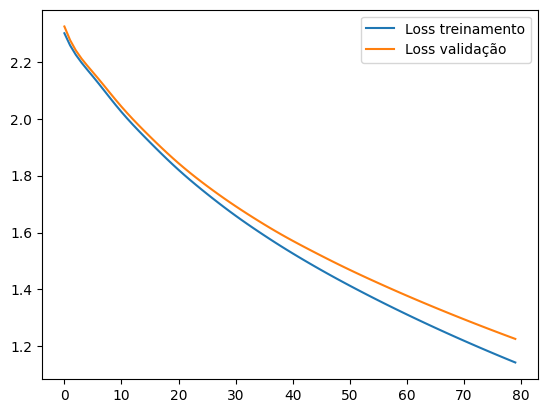

In [ ]:
plt.plot(train_losses, label='Loss treinamento')
plt.plot(val_losses, label='Loss validação')
plt.legend()
plt.show()

#### 3.3.1 Visualização dos resultados

In [ ]:
if torch.cuda.is_available():
    print("Using cuda...")
    train_x = train_x.cuda()
    val_x = val_x.cuda()

predictions = model.predict(train_x)
print(classification_report(train_y, predictions,target_names=label_names))
print("---------"*8)
print("Val set:")
predictions = model.predict(val_x)
print(classification_report(val_y, predictions,target_names=label_names))

Using cuda...
                      precision    recall  f1-score   support

              Normal       0.89      0.80      0.84       954
        Inflamatorio       0.73      0.65      0.69       769
     Menor-Densidade       0.66      0.59      0.63       486
     Maior-Densidade       0.64      0.75      0.69       458
         Obstrutivas       0.65      0.57      0.60       464
        Degenerativo       0.59      0.50      0.54       432
              Lesoes       0.65      0.76      0.70       484
Alteracoes-Midastino       0.74      0.96      0.83       411
    Alteracoes-Torax       0.86      0.99      0.92       396

            accuracy                           0.73      4854
           macro avg       0.71      0.73      0.72      4854
        weighted avg       0.73      0.73      0.72      4854

------------------------------------------------------------------------
Val set:
                      precision    recall  f1-score   support

              Normal       0.90 

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


In [ ]:
##Predição no conjunto de teste
if torch.cuda.is_available():
    print("Using cuda...")
    test_x = test_x.cuda()

predictions = model.predict(test_x)

print(classification_report(test_y, predictions,target_names=label_names))

preds_test_simple_cnn = predictions
preds_test_simple_cnn_true_y = test_y

Using cuda...
                      precision    recall  f1-score   support

              Normal       0.85      0.79      0.82       244
        Inflamatorio       0.71      0.61      0.66       201
     Menor-Densidade       0.60      0.55      0.57       124
     Maior-Densidade       0.64      0.73      0.68       111
         Obstrutivas       0.56      0.45      0.50       107
        Degenerativo       0.55      0.44      0.49       100
              Lesoes       0.50      0.69      0.58       102
Alteracoes-Midastino       0.75      0.93      0.83       124
    Alteracoes-Torax       0.88      1.00      0.94       101

            accuracy                           0.69      1214
           macro avg       0.67      0.69      0.67      1214
        weighted avg       0.69      0.69      0.69      1214



/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


#### 3.3.2 Visualização Parcial modelo simples

Para o modelo simples foi utilizado um peso de aproximadamente 2.8 para a classe "NORMAL" visto que para cada uma classe "NORMAL" existe em media 2.8 da classe "PNEUMONIA".

Text(0.5, 36.72222222222221, 'Predicted Label')

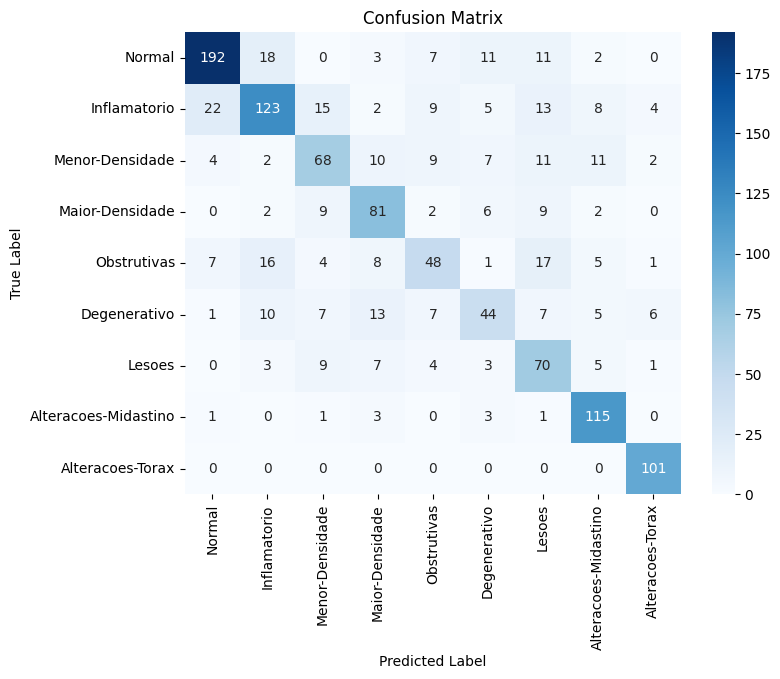

In [ ]:
cm = confusion_matrix(test_y, predictions)

# 2. Set up the plot
plt.figure(figsize=(8, 6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names)

# 4. Add labels and title for clarity
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

### 3.4 Modelo Baseado na ResNet

In [ ]:

class BasicBlock(Module):
    """
    Implements the standard ResNet Basic Block.
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()

        # 1. Convolutional Path (F(x))
        # The block consists of two 3x3 Conv layers
        self.conv1 = Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = BatchNorm2d(out_channels)
        self.relu = ReLU(inplace=True)

        self.conv2 = Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = BatchNorm2d(out_channels)

        # 2. Shortcut Connection (x)
        # Downsample the input (x) if dimensions don't match F(x)
        self.shortcut = Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = Sequential(
                Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x # Capture the input for the shortcut

        # Convolutional path
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        # Identity shortcut + Addition
        out += self.shortcut(identity)
        out = self.relu(out)
        return out

In [ ]:
class SimpleResNet(Module):
    def __init__(self, block, num_blocks, num_classes=9):
        super(SimpleResNet, self).__init__()
        self.in_channels = 64 # Starting number of filters

        # Initial Convolution (112x112x3 -> 56x56x64)
        self.conv1 = Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = BatchNorm2d(64)
        self.relu = ReLU(inplace=True)
        self.maxpool = MaxPool2d(kernel_size=3, stride=2, padding=1) # 56x56 -> 28x28

        # ResNet Stages
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1) # 28x28x64
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2) # 14x14x128

        # --- EDITED: Increase final channel count to 512 ---
        self.layer3 = self._make_layer(block, 512, num_blocks[2], stride=2) # 7x7x512
        # --- END EDIT ---

        # Global Average Pooling (7x7x512 -> 1x1x512)
        self.avgpool = AdaptiveAvgPool2d((1, 1))

        # --- EDITED: Input size must now be 512 ---
        self.fc = Linear(512, num_classes)
        # --- END EDIT ---

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride_value in strides:
            layers.append(block(self.in_channels, out_channels, stride_value))
            self.in_channels = out_channels
        return Sequential(*layers)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        # Assuming 'flatten' is defined or imported, or using torch.flatten:
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

    def predict(self, x):
        logits = self.forward(x)
        probabilities = functional.softmax(logits, dim=1)
        return torch.argmax(probabilities, dim=1).cpu().detach().numpy()




In [ ]:
# This configuration (2, 2, 2) makes it similar to a small ResNet-18.
model_resnet = SimpleResNet(BasicBlock, [3, 4, 6], num_classes=9)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

# Define the batch size (a typical value for CNNs)
BATCH_SIZE = 32

# 1. Create Datasets
train_dataset = TensorDataset(train_x, train_y)
val_dataset = TensorDataset(val_x, val_y)

# 2. Create DataLoaders (shuffling only the training data)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
optimizer = Adam(model_resnet.parameters(), lr=0.001)
# Definindo função de custo
# Adicionando peso como saida do desabalanceamento de classes.
total_sum = sum(weights_list)

# Normalize using a list comprehension
normalized_weights_lc = [w / total_sum for w in weights_list]

weights = torch.tensor(weights_list, dtype=torch.float32)
weights = weights.to(device)
criterion = CrossEntropyLoss(weight=weights)
criterion.to(device)
model_resnet.to(device)

SimpleResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True

In [ ]:
def train_and_validate(epoch,scheduler):
    # Set model to training mode
    model_resnet.train()

    current_train_loss = 0

    for batch_x, batch_y in train_loader:
        # Move batch data to GPU if available
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        # Zerando gradiente
        optimizer.zero_grad()

        # Predição e loss
        output = model_resnet(batch_x)
        loss = criterion(output, batch_y)

        # Retropropagação
        loss.backward()
        optimizer.step()

        current_train_loss += loss.item() * batch_x.size(0) # Accumulate weighted batch loss

    # Calculate average training loss for the epoch
    avg_train_loss = current_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)


    model_resnet.eval() # Set model_resnet to evaluation mode
    current_val_loss = 0
    with torch.no_grad(): # Disable gradient calculation for validation
        for batch_x_val, batch_y_val in val_loader:
            batch_x_val = batch_x_val.to(device)
            batch_y_val = batch_y_val.to(device)

            # Predição e loss
            output_val = model_resnet(batch_x_val)
            loss_val = criterion(output_val, batch_y_val)

            current_val_loss += loss_val.item() * batch_x_val.size(0)

    # Calculate average validation loss for the epoch
    avg_val_loss = current_val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)
    scheduler.step(avg_val_loss)

    if epoch % 1 == 0: # Check every epoch
        print(f'Epoch: {epoch + 1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')

In [ ]:
PATH = '/content/drive/MyDrive/Trabalho_Machine_Learning/resnetweights.pth'
train_losses = []
val_losses = []
if False and os.path.exists(PATH):
  #load weights
  model_resnet.load_state_dict(torch.load(PATH))
  model_resnet.eval()
  print(f"Model weights loaded from {PATH}")
else:
  # Treinamento do modelo
  print("Initializing training....")
  scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, min_lr=1e-7)
  n_epochs = 70 # Demora uns 8 minutos/epoca na cpu
  for epoch in range(n_epochs):
      train_and_validate(epoch,scheduler)
  torch.save(model_resnet.state_dict(), PATH)
  print(f"Model weights saved to {PATH}")

Initializing training....
Epoch: 01 | Train Loss: 0.0008 | Val Loss: 0.1019
Epoch: 02 | Train Loss: 0.0006 | Val Loss: 0.0914
Epoch: 03 | Train Loss: 0.0005 | Val Loss: 0.0879
Epoch: 04 | Train Loss: 0.0007 | Val Loss: 0.0970
Epoch: 05 | Train Loss: 0.0013 | Val Loss: 0.0918
Epoch: 06 | Train Loss: 0.0005 | Val Loss: 0.0897
Epoch: 07 | Train Loss: 0.0007 | Val Loss: 0.0878
Epoch: 08 | Train Loss: 0.0013 | Val Loss: 0.0917
Epoch: 09 | Train Loss: 0.0009 | Val Loss: 0.0959
Epoch: 10 | Train Loss: 0.0005 | Val Loss: 0.0936
Epoch: 11 | Train Loss: 0.0006 | Val Loss: 0.0943
Epoch: 12 | Train Loss: 0.0011 | Val Loss: 0.0936
Epoch: 13 | Train Loss: 0.0008 | Val Loss: 0.0974
Epoch: 14 | Train Loss: 0.0014 | Val Loss: 0.0947
Epoch: 15 | Train Loss: 0.0009 | Val Loss: 0.0946
Epoch: 16 | Train Loss: 0.0011 | Val Loss: 0.0914
Epoch: 17 | Train Loss: 0.0008 | Val Loss: 0.0907
Epoch: 18 | Train Loss: 0.0012 | Val Loss: 0.0959
Epoch: 19 | Train Loss: 0.0007 | Val Loss: 0.0897
Epoch: 20 | Train Loss: 

#### 3.4.1 Visualização dos resultados

In [ ]:
def get_predictions_and_labels(model, data_loader, device):
    """Processes data through the model batch by batch and collects results."""
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad(): # Disable gradient calculation
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            batch_predictions = model.predict(inputs)
            all_predictions.extend(batch_predictions)
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_labels), np.array(all_predictions)

In [ ]:
train_eval_dataset = TensorDataset(train_x, train_y)
val_eval_dataset = TensorDataset(val_x, val_y)
test_eval_dataset = TensorDataset(test_x, test_y)

train_eval_loader = DataLoader(train_eval_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_eval_loader = DataLoader(val_eval_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_eval_loader = DataLoader(test_eval_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# 3. Get predictions and labels for Training Set
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_resnet.to(device) # Ensure the model is on the correct device

train_y_true, train_predictions = get_predictions_and_labels(model_resnet, train_eval_loader, device)
print("--- Training Set Report ---")
print(classification_report(train_y_true, train_predictions, target_names=label_names))

print("-" * 64)

# 4. Get predictions and labels for Validation Set
val_y_true, val_predictions = get_predictions_and_labels(model_resnet, val_eval_loader, device)
print("--- Validation Set Report ---")
print(classification_report(val_y_true, val_predictions, target_names=label_names))

--- Training Set Report ---
                      precision    recall  f1-score   support

              Normal       1.00      1.00      1.00       954
        Inflamatorio       1.00      1.00      1.00       769
     Menor-Densidade       1.00      1.00      1.00       486
     Maior-Densidade       1.00      1.00      1.00       458
         Obstrutivas       1.00      1.00      1.00       464
        Degenerativo       1.00      1.00      1.00       432
              Lesoes       1.00      1.00      1.00       484
Alteracoes-Midastino       1.00      1.00      1.00       411
    Alteracoes-Torax       1.00      1.00      1.00       396

            accuracy                           1.00      4854
           macro avg       1.00      1.00      1.00      4854
        weighted avg       1.00      1.00      1.00      4854

----------------------------------------------------------------
--- Validation Set Report ---
                      precision    recall  f1-score   support

     

In [ ]:
test_y_true, test_predictions = get_predictions_and_labels(model_resnet, test_eval_loader, device)
print("--- Test Set Report ---")
print(classification_report(test_y_true, test_predictions, target_names=label_names))

preds_test_resnet_cnn = test_predictions
preds_test_resnet_cnn_true_y = test_y_true

--- Test Set Report ---
                      precision    recall  f1-score   support

              Normal       0.96      0.96      0.96       244
        Inflamatorio       0.97      0.94      0.95       201
     Menor-Densidade       0.99      1.00      1.00       124
     Maior-Densidade       0.98      1.00      0.99       111
         Obstrutivas       0.95      0.95      0.95       107
        Degenerativo       1.00      0.98      0.99       100
              Lesoes       0.97      1.00      0.99       102
Alteracoes-Midastino       0.99      1.00      1.00       124
    Alteracoes-Torax       0.99      1.00      1.00       101

            accuracy                           0.98      1214
           macro avg       0.98      0.98      0.98      1214
        weighted avg       0.98      0.98      0.98      1214



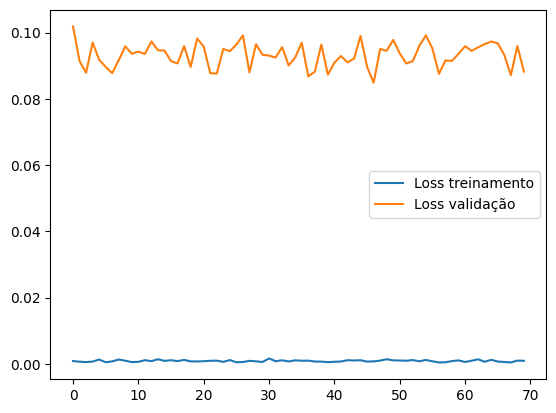

In [ ]:
plt.plot(train_losses, label='Loss treinamento')
plt.plot(val_losses, label='Loss validação')
plt.legend()
plt.show()

#### 3.4.2 Visualização Parcial Resnet

Text(0.5, 36.72222222222221, 'Predicted Label')

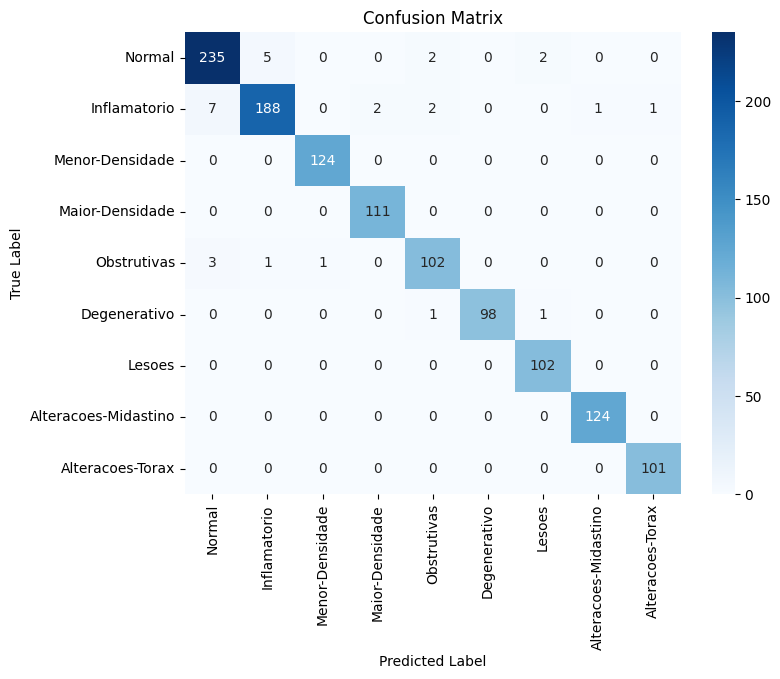

In [ ]:
cm = confusion_matrix(test_y_true, test_predictions)

# 2. Set up the plot
plt.figure(figsize=(8, 6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names)

# 4. Add labels and title for clarity
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

### 3.5 Autoencoder + CNN Simples -> falta testar

In [ ]:

class ConvAutoencoder(Module):
    def __init__(self):
        super(ConvAutoencoder, self).__init__()

        # --- Encoder (Feature Extraction) ---
        self.encoder = Sequential(
            # 112x112x3 -> 56x56x16
            Conv2d(3, 16, kernel_size=3, stride=2, padding=1),
            ReLU(True),
            # 56x56x16 -> 28x28x32
            Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            ReLU(True),
            # 28x28x32 -> 14x14x64
            Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            ReLU(True),
            # Latent space output (14x14x64). We'll flatten this for the dense layer if needed,
            # but usually, we keep it convolutional for easy transfer.
        )

        # --- Decoder (Image Reconstruction) ---
        self.decoder = Sequential(
            # 14x14x64 -> 28x28x32 (using ConvTranspose2d for upsampling)
            ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            ReLU(True),
            # 28x28x32 -> 56x56x16
            ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            ReLU(True),
            # 56x56x16 -> 112x112x3 (Final reconstruction)
            ConvTranspose2d(16, 3, kernel_size=3, stride=2, padding=1, output_padding=1),
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [ ]:
class ClassifierFromCAE(Module):
    def __init__(self, pretrained_encoder, num_classes=9):
        super(ClassifierFromCAE, self).__init__()

        # 1. Substitui a 'cnn_layers' pelo encoder pré-treinado
        self.feature_extractor = pretrained_encoder

        # 2. Ajuste o Linear Layer para o tamanho de saída do encoder
        # O encoder finaliza em 64 canais com tamanho 14x14
        # 64 * 14 * 14 = 12544
        LATENT_SIZE = 64 * 14 * 14

        self.linear_layers = Sequential(
            # Camada linear intermediária opcional (pode ajudar)
            Linear(LATENT_SIZE, 256),
            ReLU(True),
            # Camada de classificação final
            Linear(256, num_classes)
        )

        # Softmax no forward não é necessário se estiver usando CrossEntropyLoss,
        # mas mantemos para o método predict.
        self.softmax = Softmax(dim=1)

    def forward(self, x):
        x = self.feature_extractor(x) # Passa pela arquitetura do encoder (3 -> 64 canais)
        x = flatten(x, 1)             # Achata de (N, 64, 14, 14) para (N, 12544)
        x = self.linear_layers(x)
        return x

    def predict(self, x):
        logits = self.forward(x)
        softmax = self.softmax(logits)
        prob = softmax.cpu().detach().numpy()
        return np.argmax(prob, axis=1) # Corrigido para retornar o índice de maior probabilidade

In [ ]:
def denormalize(tensor, mean, std):
    """Reverte a normalização para visualização correta"""
    tensor = tensor.clone().detach().cpu()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m) # Multiplica pelo STD e soma a MEAN
    return tensor

In [ ]:
def visualize_reconstruction(autoencoder_model, data_loader, device, num_images=5):
    autoencoder_model.eval()
    images_to_show = []

    with torch.no_grad():
        for i, (batch_x, _) in enumerate(data_loader):
            if len(images_to_show) >= num_images:
                break

            batch_x = batch_x.to(device)
            reconstructed_batch = autoencoder_model(batch_x)

            for j in range(batch_x.shape[0]):
                if len(images_to_show) >= num_images:
                    break

                # --- AQUI ESTÁ A MÁGICA: DESNORMALIZAR ---
                orig = denormalize(batch_x[j], mean, std)
                recon = denormalize(reconstructed_batch[j], mean, std)

                images_to_show.append((orig, recon))

    # Plotting
    fig, axes = plt.subplots(num_images, 2, figsize=(8, 3 * num_images))
    for i, (original_img, reconstructed_img) in enumerate(images_to_show):
        # PyTorch (C, H, W) -> Matplotlib (H, W, C)
        original_img = original_img.permute(1, 2, 0).numpy()
        reconstructed_img = reconstructed_img.permute(1, 2, 0).numpy()

        # Clip final só para garantir que nada passe de 0 ou 1 por erro de arredondamento
        original_img = np.clip(original_img, 0, 1)
        reconstructed_img = np.clip(reconstructed_img, 0, 1)

        axes[i, 0].imshow(original_img)
        axes[i, 0].set_title(f"Original {i+1}")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(reconstructed_img)
        axes[i, 1].set_title(f"Reconstructed {i+1}")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
autoencoder = ConvAutoencoder().to(device)

# Use Mean Squared Error (MSE) Loss for reconstruction
criterion_ae = MSELoss()

# Use a specific, small learning rate for Autoencoders
# They are often trained slowly for better convergence.
optimizer_ae = Adam(autoencoder.parameters(), lr=0.001)

In [ ]:
def train_autoencoder(model, train_loader, criterion, optimizer, device, num_epochs=50):
    print("Starting Autoencoder Pre-training...")
    model.train()

    for epoch in range(num_epochs):
        running_loss = 0.0

        for batch_x, _ in train_loader: # Labels are ignored here
            # Move input data to the device
            batch_x = batch_x.to(device)

            # Zero gradients
            optimizer.zero_grad()

            # Forward pass: Reconstruction
            reconstructions = model(batch_x)

            # Calculate loss: MSE between original and reconstructed image
            loss = criterion(reconstructions, batch_x)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * batch_x.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.6f}')

    print("Autoencoder training complete.")
    return model

In [ ]:
# --- 3. Execution and Saving ---
NUM_EPOCHS_AE = 200 # Start with 50, but you might need more (100-200)
AE_PATH = 'autoencoder_weights.pth'

# Check if weights exist (optional)
# if not os.path.exists(AE_PATH):
final_autoencoder = train_autoencoder(
    autoencoder,
    train_loader, # Use your existing train_loader
    criterion_ae,
    optimizer_ae,
    device,
    NUM_EPOCHS_AE
)
torch.save(final_autoencoder.state_dict(), AE_PATH)
print(f"Autoencoder weights saved to {AE_PATH}")

Starting Autoencoder Pre-training...
Epoch [1/200], Loss: 0.206256
Epoch [2/200], Loss: 0.038394
Epoch [3/200], Loss: 0.028906
Epoch [4/200], Loss: 0.023208
Epoch [5/200], Loss: 0.019833
Epoch [6/200], Loss: 0.017984
Epoch [7/200], Loss: 0.016424
Epoch [8/200], Loss: 0.014454
Epoch [9/200], Loss: 0.014095
Epoch [10/200], Loss: 0.012654
Epoch [11/200], Loss: 0.012177
Epoch [12/200], Loss: 0.011898
Epoch [13/200], Loss: 0.011129
Epoch [14/200], Loss: 0.010811
Epoch [15/200], Loss: 0.010108
Epoch [16/200], Loss: 0.009955
Epoch [17/200], Loss: 0.009439
Epoch [18/200], Loss: 0.009271
Epoch [19/200], Loss: 0.009040
Epoch [20/200], Loss: 0.008763
Epoch [21/200], Loss: 0.008408
Epoch [22/200], Loss: 0.008266
Epoch [23/200], Loss: 0.007818
Epoch [24/200], Loss: 0.007866
Epoch [25/200], Loss: 0.007971
Epoch [26/200], Loss: 0.007324
Epoch [27/200], Loss: 0.006835
Epoch [28/200], Loss: 0.007103
Epoch [29/200], Loss: 0.006535
Epoch [30/200], Loss: 0.006531
Epoch [31/200], Loss: 0.006174
Epoch [32/2

Pesos do Autoencoder carregados com sucesso de autoencoder_weights.pth


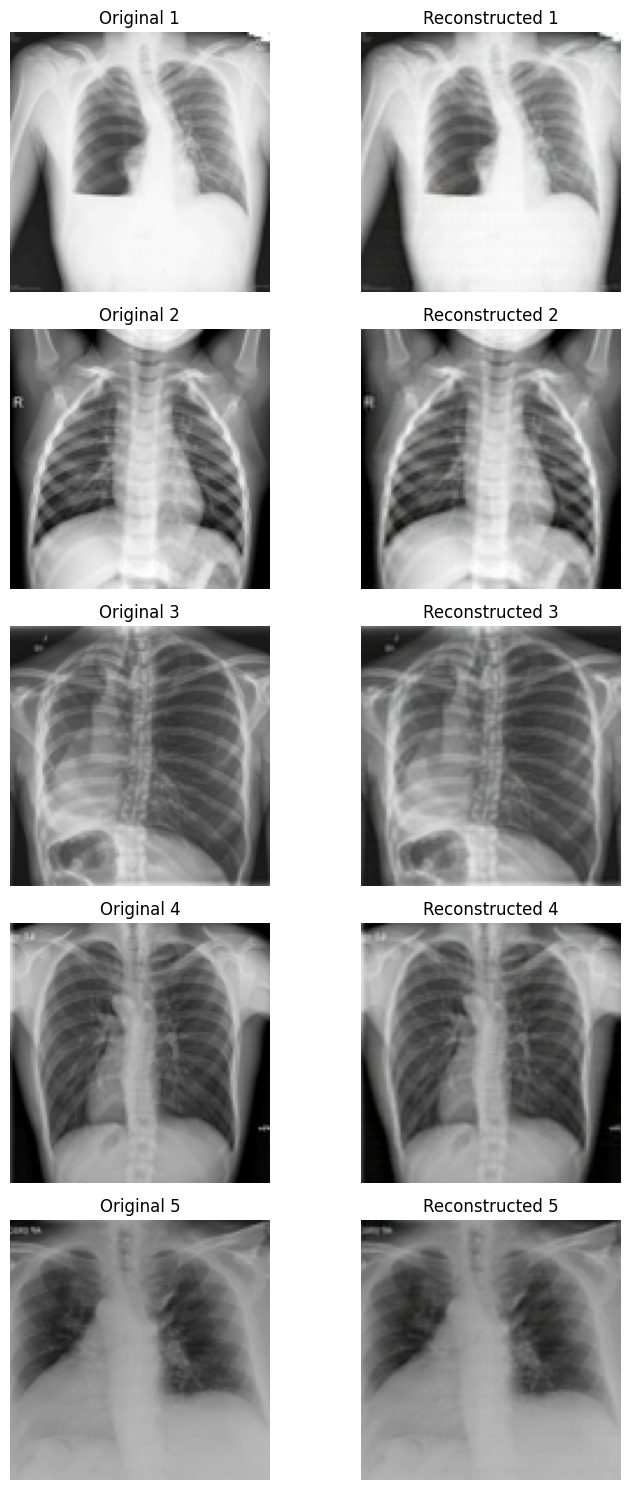

In [ ]:
autoencoder = ConvAutoencoder().to(device)

# 2. Carregar os pesos
try:
    autoencoder.load_state_dict(torch.load(AE_PATH, map_location=device))
    print(f"Pesos do Autoencoder carregados com sucesso de {AE_PATH}")
except FileNotFoundError:
    print(f"Erro: Arquivo de pesos '{AE_PATH}' não encontrado. Verifique o caminho.")
    # Se os pesos não forem carregados, a visualização será inútil, mas o código não quebrará.

# 3. Chamar a função de visualização
# OBS: Use seu DataLoader de teste ou validação (que contém as imagens normalizadas)
visualize_reconstruction(autoencoder, test_eval_loader, device, num_images=5)

In [ ]:
trained_autoencoder = ConvAutoencoder()
trained_autoencoder.load_state_dict(torch.load(AE_PATH, map_location=device))
pretrained_encoder = trained_autoencoder.encoder

# 3. Inicializar o NOVO MODELO (Substituindo o antigo 'model')
# OBS: O seu loop usa a variável 'model', garanta que seu novo modelo use esse nome.
model = ClassifierFromCAE(pretrained_encoder, num_classes=9).to(device)

for param in model.feature_extractor.parameters():
    param.requires_grad = False

# 4. Inicializar o Otimizador (com a taxa de aprendizado baixa para fine-tuning)
optimizer = Adam(model.parameters(), lr=0.00002)
criterion = CrossEntropyLoss().to(device)

In [ ]:
model.to(device)

ClassifierFromCAE(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU(inplace=True)
  )
  (linear_layers): Sequential(
    (0): Linear(in_features=12544, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=256, out_features=9, bias=True)
  )
  (softmax): Softmax(dim=1)
)

In [ ]:
from torch.autograd import Variable # Mantenha a importação para evitar erros de sintaxe, mas o uso é removido.

# A função assume que 'device' foi definido no escopo global/externo.

def train(epoch):
    model.train()
    tr_loss = 0

    x_train, y_train = train_x.to(device), train_y.to(device)
    x_val, y_val = val_x.to(device), val_y.to(device)

    # Zerando gradiente
    optimizer.zero_grad()

    # Predição pros conjuntos de treino e validação
    output_train = model(x_train)
    output_val = model(x_val)

    # Computando loss do treino e da validação
    loss_train = criterion(output_train, y_train)
    loss_val = criterion(output_val, y_val)
    train_losses.append(loss_train.item())
    val_losses.append(loss_val.item())

    # Retropropagação
    loss_train.backward()
    optimizer.step()
    tr_loss = loss_train.item()
    if epoch % 2 == 0:
        # Printando loss de validação
        print('Epoch : ', epoch + 1, '\t', 'loss :', loss_val.item())

In [ ]:
train_losses = []
val_losses = []
n_epochs = 80

# --- 3. LOOP DE TREINAMENTO ---
for epoch in range(n_epochs):

    # --- A MÁGICA ACONTECE AQUI (Na época 20) ---
    if epoch == 40:
        print("\n" + "="*40)
        print(f">>> Época {epoch}: DESCONGELANDO O ENCODER (Iniciando Fine-Tuning)")
        print("="*40 + "\n")

        # 1. Liberar os pesos do encoder para serem alterados
        for param in model.feature_extractor.parameters():
            param.requires_grad = True

        # 2. REDUZIR O LEARNING RATE (Crucial!)
        # Agora que vamos mexer no encoder delicado, diminuímos o LR para 0.00002 (seu valor original)
        # para não "quebrar" o que o autoencoder já aprendeu.
        for param_group in optimizer.param_groups:
            param_group['lr'] = 0.00002

        print("Learning Rate reduzido para 0.00002")

    # Chama sua função de treino
    train(epoch)

Epoch :  1 	 loss : 2.248181104660034
Epoch :  3 	 loss : 2.1001667976379395
Epoch :  5 	 loss : 2.053469657897949
Epoch :  7 	 loss : 1.9631301164627075
Epoch :  9 	 loss : 1.8803061246871948
Epoch :  11 	 loss : 1.8299236297607422
Epoch :  13 	 loss : 1.7799468040466309
Epoch :  15 	 loss : 1.727778673171997
Epoch :  17 	 loss : 1.6909211874008179
Epoch :  19 	 loss : 1.6524927616119385
Epoch :  21 	 loss : 1.6084784269332886
Epoch :  23 	 loss : 1.5714020729064941
Epoch :  25 	 loss : 1.538852572441101
Epoch :  27 	 loss : 1.506601333618164
Epoch :  29 	 loss : 1.4787755012512207
Epoch :  31 	 loss : 1.4505873918533325
Epoch :  33 	 loss : 1.4207801818847656
Epoch :  35 	 loss : 1.3950777053833008
Epoch :  37 	 loss : 1.371933102607727
Epoch :  39 	 loss : 1.3494651317596436

>>> Época 40: DESCONGELANDO O ENCODER (Iniciando Fine-Tuning)

Learning Rate reduzido para 0.00002
Epoch :  41 	 loss : 1.3272478580474854
Epoch :  43 	 loss : 1.3035438060760498
Epoch :  45 	 loss : 1.28177559

#### 3.5.1 Visualização dos Resultados

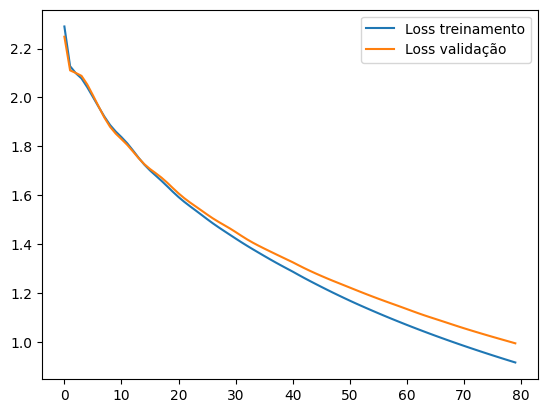

In [ ]:
plt.plot(train_losses, label='Loss treinamento')
plt.plot(val_losses, label='Loss validação')
plt.legend()
plt.show()

In [ ]:
##Predição no conjunto de teste
if torch.cuda.is_available():
    print("Using cuda...")
    test_x = test_x.cuda()

predictions = model.predict(test_x)

print(classification_report(test_y, predictions,target_names=label_names))

preds_test_simple_autoencoder_cnn = predictions
preds_test_simple_cnn_true_y_autoencoder = test_y

Using cuda...
                      precision    recall  f1-score   support

              Normal       0.83      0.87      0.85       244
        Inflamatorio       0.76      0.78      0.77       201
     Menor-Densidade       0.65      0.58      0.61       124
     Maior-Densidade       0.83      0.83      0.83       111
         Obstrutivas       0.58      0.46      0.51       107
        Degenerativo       0.75      0.51      0.61       100
              Lesoes       0.61      0.81      0.69       102
Alteracoes-Midastino       0.87      0.94      0.90       124
    Alteracoes-Torax       0.94      1.00      0.97       101

            accuracy                           0.77      1214
           macro avg       0.76      0.75      0.75      1214
        weighted avg       0.77      0.77      0.76      1214



#### 3.5.2 Visualização Parcial

Text(0.5, 36.72222222222221, 'Predicted Label')

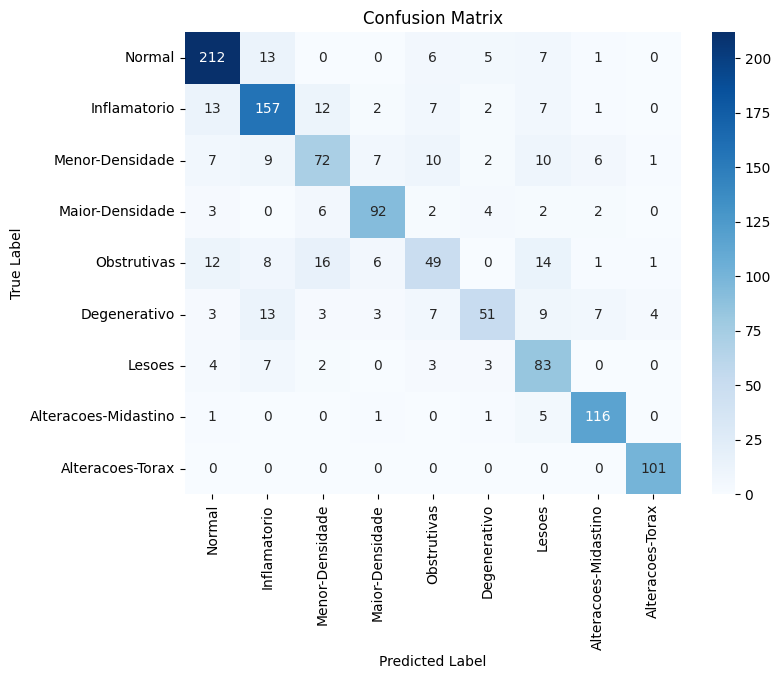

In [ ]:
cm = confusion_matrix(test_y, predictions)

# 2. Set up the plot
plt.figure(figsize=(8, 6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names)

# 4. Add labels and title for clarity
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

### Visualização

Salvei nas variaveis:
- preds_test_simple_cnn, preds_test_simple_cnn_true_y
- preds_test_resnet_cnn, preds_test_resnet_cnn_true_y

Os resultados desse modelo simples, para no futuro avaliar os diferentes modelos de uma vez.

In [ ]:
true_classes = preds_test_resnet_cnn_true_y
pred_classes = preds_test_resnet_cnn

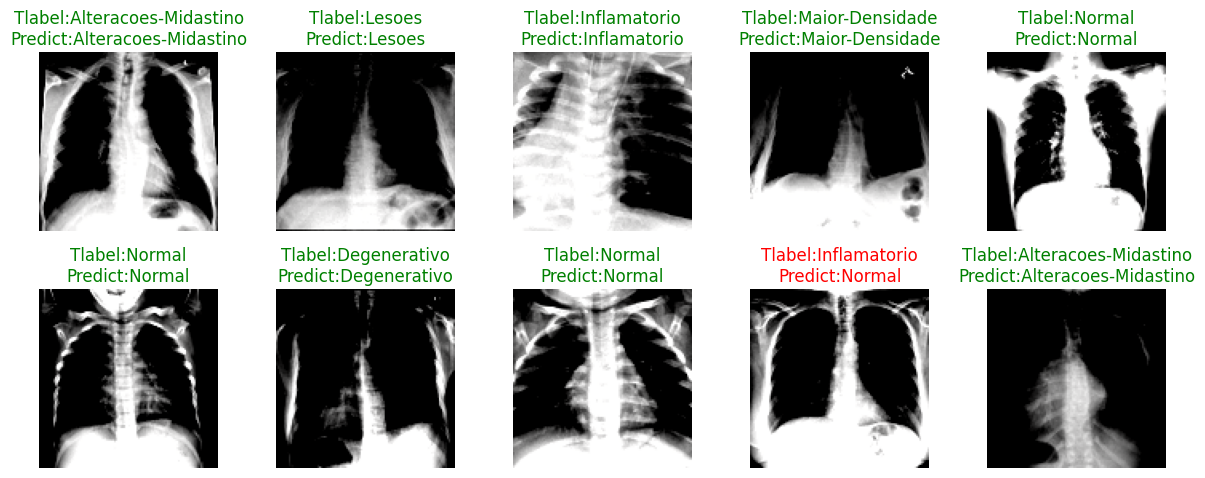

In [ ]:
n_to_show = 10
plt.figure(figsize=(12, 12))
printed=False

for i in range(n_to_show):
    idx = np.random.randint(0, len(test_x))

    image = test_x[idx]
    # Convert torch tensor → numpy
    if hasattr(image, "numpy"):
        img_np = image.detach().cpu().numpy()       # to numpy
        img_np = img_np.transpose(1, 2, 0)
        image = img_np

    # Ensure float in [0,1] or uint8
    image = np.array(image)

    true_label = true_classes[idx]
    pred_label = pred_classes[idx]

    plt.subplot(5, 5, i+1)
    plt.imshow(image)  # already 112×112×3 RGB
    color = "green" if true_label == pred_label else "red"
    plt.title(f"Tlabel:{label_names[true_label]}\nPredict:{label_names[pred_label]}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()



# **4. Resultados e Análise**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
model_results = [
    {
        "name": "Simple CNN",
        "preds": preds_test_simple_cnn,
        "true": preds_test_simple_cnn_true_y
    },
    {
        "name": "Autoencoder + CNN",
        "preds": preds_test_simple_autoencoder_cnn,
        "true": preds_test_simple_cnn_true_y_autoencoder
    },
    {
        "name": "ResNet",
        "preds": preds_test_resnet_cnn,
        "true": preds_test_resnet_cnn_true_y
    }
]

--- Comparativo Global ---


,Modelo,Acurácia,Precisão (W),Recall (W),F1-Score (W)
0,Simple CNN,0.6936,0.6935,0.6936,0.6889
1,Autoencoder + CNN,0.7685,0.7658,0.7685,0.7628
2,ResNet,0.9761,0.9761,0.9761,0.9760


/tmp/ipython-input-2119825276.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Modelo", y="Acurácia", data=df_metrics, palette="viridis")


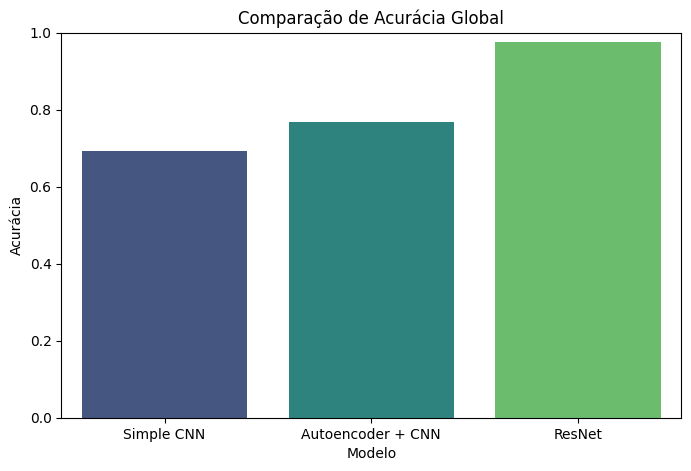

In [ ]:
metrics_list = []

for model in model_results:
    acc = accuracy_score(model['true'], model['preds'])
    # weighted leva em conta o desbalanceamento das classes
    precision, recall, f1, _ = precision_recall_fscore_support(
        model['true'], model['preds'], average='weighted'
    )

    metrics_list.append({
        "Modelo": model['name'],
        "Acurácia": acc,
        "Precisão (W)": precision,
        "Recall (W)": recall,
        "F1-Score (W)": f1
    })

df_metrics = pd.DataFrame(metrics_list)
# Arredondando para leitura fácil
df_metrics = df_metrics.round(4)

print("--- Comparativo Global ---")
display(df_metrics) # O Colab exibe tabelas do Pandas formatadas automaticamente

# Gráfico simples da Acurácia
plt.figure(figsize=(8, 5))
sns.barplot(x="Modelo", y="Acurácia", data=df_metrics, palette="viridis")
plt.ylim(0, 1.0)
plt.title("Comparação de Acurácia Global")
plt.ylabel("Acurácia")
plt.show()

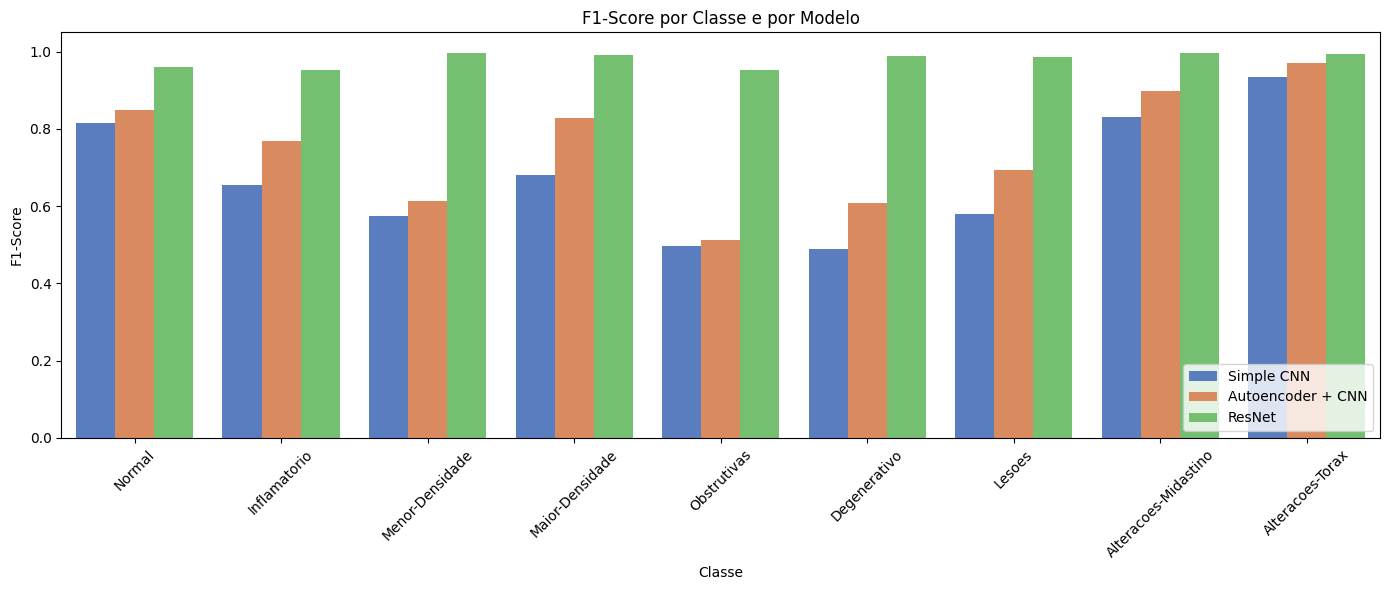

In [ ]:
class_metrics = []

for model in model_results:
    # average=None retorna as métricas para cada classe individualmente
    precision, recall, f1, _ = precision_recall_fscore_support(
        model['true'], model['preds'], average=None
    )

    for i, class_name in enumerate(label_names):
        class_metrics.append({
            "Modelo": model['name'],
            "Classe": class_name,
            "F1-Score": f1[i]
        })

df_class = pd.DataFrame(class_metrics)

# Plotando
plt.figure(figsize=(14, 6))
sns.barplot(x="Classe", y="F1-Score", hue="Modelo", data=df_class, palette="muted")
plt.title("F1-Score por Classe e por Modelo")
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import cohen_kappa_score, matthews_corrcoef

comparison_data = []

for model in model_results:
    kappa = cohen_kappa_score(model['true'], model['preds'])
    mcc = matthews_corrcoef(model['true'], model['preds'])

    comparison_data.append({
        "Modelo": model['name'],
        "Cohen's Kappa": kappa,
        "MCC": mcc
    })

df_advanced = pd.DataFrame(comparison_data).round(4)
print("--- Métricas de Robustez ---")
# Interpretando: Kappa > 0.8 é excelente, < 0.4 é ruim.
display(df_advanced)

--- Métricas de Robustez ---


,Modelo,Cohen's Kappa,MCC
0,Simple CNN,0.6508,0.6520
1,Autoencoder + CNN,0.7349,0.7358
2,ResNet,0.9727,0.9727


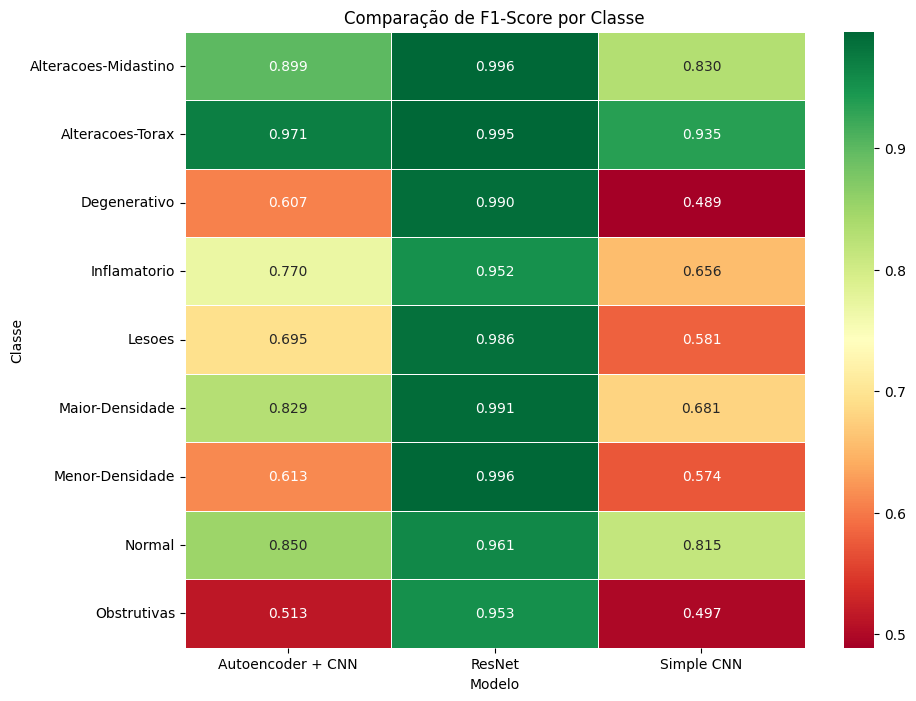

In [ ]:
# Preparar dados
heatmap_data = []

for model in model_results:
    precision, recall, f1, _ = precision_recall_fscore_support(
        model['true'], model['preds'], average=None
    )
    for i, score in enumerate(f1):
        heatmap_data.append({
            "Modelo": model['name'],
            "Classe": label_names[i],
            "F1-Score": score
        })

df_heatmap = pd.DataFrame(heatmap_data)
# Pivotar para formato de matriz (Linhas: Classes, Colunas: Modelos)
df_pivot = df_heatmap.pivot(index="Classe", columns="Modelo", values="F1-Score")

# Plotar
plt.figure(figsize=(10, 8))
sns.heatmap(df_pivot, annot=True, cmap="RdYlGn", fmt=".3f", linewidths=.5)
plt.title("Comparação de F1-Score por Classe")
plt.show()

In [ ]:
def get_top_errors(y_true, y_pred, labels, model_name, top_n=3):
    cm = confusion_matrix(y_true, y_pred)
    np.fill_diagonal(cm, 0) # Zerar a diagonal (acertos) para achar só erros

    errors = []
    for i in range(len(labels)):
        for j in range(len(labels)):
            if cm[i, j] > 0:
                errors.append({
                    "Real": labels[i],
                    "Predito": labels[j],
                    "Quantidade": cm[i, j],
                    "Modelo": model_name
                })

    # Ordenar pelos erros mais frequentes
    df_errors = pd.DataFrame(errors)
    if not df_errors.empty:
        return df_errors.sort_values(by="Quantidade", ascending=False).head(top_n)
    return pd.DataFrame()

print("--- Top 3 Confusões por Modelo ---")
for model in model_results:
    print(f"\nMODELO: {model['name']}")
    display(get_top_errors(model['true'], model['preds'], label_names, model['name']))

--- Top 3 Confusões por Modelo ---

MODELO: Simple CNN


,Real,Predito,Quantidade,Modelo
6,Inflamatorio,Normal,22,Simple CNN
0,Normal,Inflamatorio,18,Simple CNN
33,Obstrutivas,Lesoes,17,Simple CNN



MODELO: Autoencoder + CNN


,Real,Predito,Quantidade,Modelo
28,Obstrutivas,Menor-Densidade,16,Autoencoder + CNN
30,Obstrutivas,Lesoes,14,Autoencoder + CNN
0,Normal,Inflamatorio,13,Autoencoder + CNN



MODELO: ResNet


,Real,Predito,Quantidade,Modelo
3,Inflamatorio,Normal,7,ResNet
0,Normal,Inflamatorio,5,ResNet
8,Obstrutivas,Normal,3,ResNet


# **5. Conclusão**
Por fim, a CNN Simples alcançou apenas 69,36% de acurácia. Constatou-se que o uso do Autoencoder associado à CNN, embora tenha superado a rede simples ao atingir 76,85%, não obteve os melhores resultados, demonstrando dificuldades em capturar as características necessárias para distinguir classes visualmente complexas.

Em contrapartida, a aplicação de Transfer Learning com a ResNet apresentou um desempenho consideravelmente superior, alcançando uma acurácia global de 97,61% e métricas consistentes em todas as classes. Conclui-se que o reaproveitamento de características pré-treinadas é a estratégia mais eficaz para este conjunto de dados, superando a capacidade de generalização das arquiteturas baseadas apenas em Autoencoders ou CNNs simples.